# Deep Learning PRO — Clase 2  
## Entrenamiento profundo, estabilidad numérica, regularización y TensorFlow a nivel ingeniería

**Objetivo de la clase**  
Pasar de “usar redes neuronales” a entender **cómo hacer que entrenen bien** y cómo controlar el proceso de entrenamiento de forma más profesional.

---

## Ruta de la clase

1. ¿Por qué es difícil entrenar redes profundas?  
2. Vanishing y exploding gradients  
3. Inicialización de pesos  
4. Batch Normalization  
5. Optimizadores y learning rate  
6. Regularización: Dropout, L2, Early Stopping  
7. GradientTape y training loops custom  
8. Cómo conectar esto con problemas reales de negocio

Autor: Josef Rodriguez


# 1. El verdadero reto: entrenar profundo

Construir una red es relativamente fácil.  
Hacer que entrene bien, converja de forma estable y generalice correctamente es otra historia.

## Problemas típicos

- gradientes que desaparecen
- gradientes que explotan
- mala inicialización
- learning rate inadecuado
- overfitting
- entrenamiento inestable
- alta sensibilidad a hiperparámetros

# 2. Vanishing Gradient

## Definición
El gradiente se vuelve extremadamente pequeño a medida que retrocede por muchas capas.

## Consecuencia
Las capas iniciales apenas actualizan sus parámetros.

## Intuición matemática
Durante backpropagation se multiplican muchas derivadas.  
Si muchas de ellas son menores que 1, el producto total tiende a cero.

## Dónde era más común
- redes profundas con sigmoid o tanh
- arquitecturas antiguas mal inicializadas

# 3. Exploding Gradient

## Definición
El gradiente crece sin control durante la retropropagación.

## Consecuencias
- entrenamiento inestable
- pérdidas enormes
- parámetros que divergen
- NaNs

## Soluciones comunes
- buena inicialización
- gradient clipping
- arquitectura más estable
- optimizadores adecuados

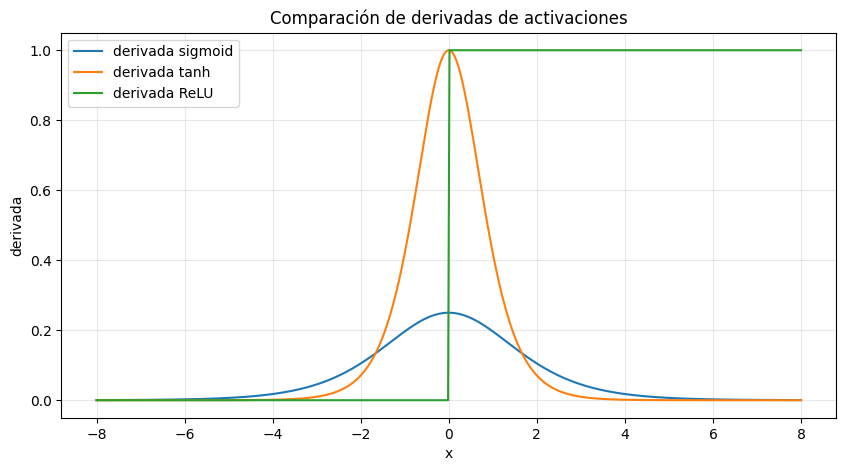

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-8, 8, 500)
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_deriv = sigmoid * (1 - sigmoid)

tanh = np.tanh(x)
tanh_deriv = 1 - tanh**2

relu_deriv = np.where(x > 0, 1, 0)

plt.figure(figsize=(10, 5))
plt.plot(x, sigmoid_deriv, label="derivada sigmoid")
plt.plot(x, tanh_deriv, label="derivada tanh")
plt.plot(x, relu_deriv, label="derivada ReLU")
plt.title("Comparación de derivadas de activaciones")
plt.xlabel("x")
plt.ylabel("derivada")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Lectura del gráfico

- Las derivadas de **sigmoid** y **tanh** tienden a valores muy pequeños en zonas de saturación.
- **ReLU** mantiene derivada 1 en la región positiva, lo que ayuda al flujo del gradiente.

Esto no elimina todos los problemas, pero sí explica por qué ReLU cambió la práctica moderna.

# 4. Inicialización de pesos

Inicializar pesos al azar no significa “de cualquier manera”.

## Objetivo de una buena inicialización
Mantener una escala razonable de activaciones y gradientes a través de las capas.

## Xavier / Glorot
Adecuada en varios contextos, especialmente con activaciones simétricas.

## He Initialization
Especialmente útil con ReLU y variantes.

### Idea
Si la inicialización es demasiado grande:
- activaciones explotan

Si es demasiado pequeña:
- la señal desaparece

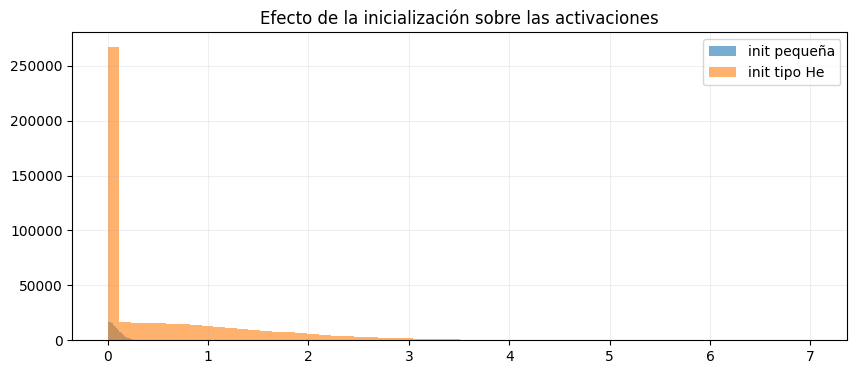

In [2]:
rng = np.random.default_rng(42)
n_in = 100
samples = 5000

x = rng.normal(size=(samples, n_in))

# Inicialización muy pequeña
W_small = rng.normal(scale=0.01, size=(n_in, 100))
h_small = np.maximum(0, x @ W_small)

# Inicialización razonable tipo He aproximada
W_he = rng.normal(scale=np.sqrt(2 / n_in), size=(n_in, 100))
h_he = np.maximum(0, x @ W_he)

plt.figure(figsize=(10, 4))
plt.hist(h_small.ravel(), bins=60, alpha=0.6, label="init pequeña")
plt.hist(h_he.ravel(), bins=60, alpha=0.6, label="init tipo He")
plt.title("Efecto de la inicialización sobre las activaciones")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 5. Batch Normalization

## Definición
Técnica que normaliza activaciones intermedias para estabilizar el entrenamiento.


\[
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}
\]


Después se añaden parámetros entrenables para reescalar y recentrar.

## Beneficios prácticos

- entrenamiento más estable
- convergencia más rápida
- permite learning rates mayores
- ayuda a regularizar parcialmente

## Importante
No es una bala de plata.  
Es una técnica muy útil, pero depende del contexto y de la arquitectura.

# 6. Optimizadores

El optimizador decide cómo actualizar los parámetros.

## SGD
\[
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}
\]

Simple, pero puede ser lento.

## Momentum
Acumula dirección histórica para avanzar con más estabilidad.

## RMSProp
Ajusta el tamaño del paso según la magnitud histórica de los gradientes.

## Adam
Combina ideas de momentum y escalado adaptativo.  
Es uno de los optimizadores más usados en práctica.

# 7. Learning Rate: el hiperparámetro más delicado

## Si el learning rate es muy alto
- el modelo oscila
- puede divergir

## Si es muy bajo
- entrena muy lento
- puede quedarse en soluciones pobres

## Schedules útiles
- step decay
- exponential decay
- ReduceLROnPlateau
- cosine decay

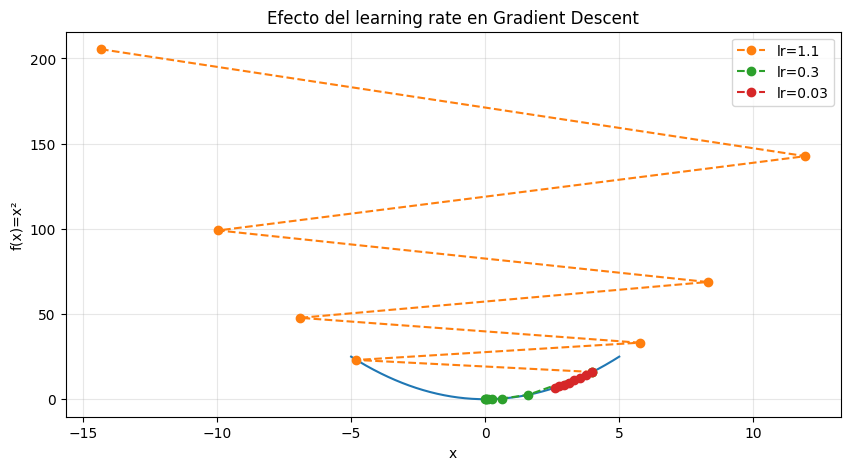

In [3]:
eta_values = [1.1, 0.3, 0.03]
x = np.linspace(-5, 5, 500)
y = x**2

plt.figure(figsize=(10, 5))
plt.plot(x, y)

for eta in eta_values:
    x0 = 4.0
    xs, ys = [], []
    for _ in range(8):
        xs.append(x0)
        ys.append(x0**2)
        grad = 2 * x0
        x0 = x0 - eta * grad
    plt.plot(xs, ys, marker="o", linestyle="--", label=f"lr={eta}")

plt.title("Efecto del learning rate en Gradient Descent")
plt.xlabel("x")
plt.ylabel("f(x)=x²")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. Regularización

## Objetivo
Mejorar la generalización del modelo, no solo su rendimiento en entrenamiento.

## L2 Regularization
\[
\mathcal{L}_{total} = \mathcal{L} + \lambda \|W\|_2^2
\]

Penaliza pesos excesivamente grandes.

## Dropout
Desactiva neuronas aleatoriamente durante entrenamiento.  
Obliga a la red a no depender demasiado de un subconjunto de unidades.

## Early Stopping
Detiene el entrenamiento cuando validation loss deja de mejorar.

## Gradient Clipping
Recorta gradientes extremos para evitar inestabilidad.

# 9. Overfitting en práctica

La pregunta no es solo si la red aprende.  
La pregunta correcta es si aprende **de forma útil fuera de muestra**.

## Señales visuales
- `train_loss` sigue bajando
- `val_loss` se estanca o sube

## Diagnóstico
Eso sugiere que el modelo está capturando ruido o estructura demasiado específica del entrenamiento.

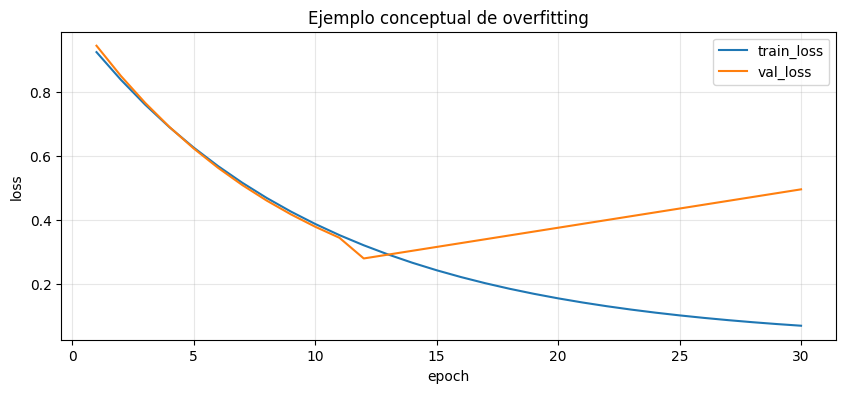

In [4]:
epochs = np.arange(1, 31)
train_loss = np.exp(-epochs / 10) + 0.02
val_loss = np.where(epochs < 12,
                    np.exp(-epochs / 9) + 0.05,
                    0.28 + (epochs - 12) * 0.012)

plt.figure(figsize=(10, 4))
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.title("Ejemplo conceptual de overfitting")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 10. Ejemplo pro con Keras: BatchNorm, Dropout y callbacks

Vamos a crear un modelo más serio que el de la clase 1.

## Qué queremos enseñar
- arquitectura un poco más robusta
- Batch Normalization
- Dropout
- EarlyStopping
- ReduceLROnPlateau

In [21]:
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=3500,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    class_sep=1.0,
    flip_y=0.03,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, kernel_initializer="he_normal", input_shape=(X_train_sc.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(32, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5
    )
]

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)

test_metrics = model.evaluate(X_test_sc, y_test, verbose=0)
print(dict(zip(model.metrics_names, test_metrics)))

/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'loss': 0.14853988587856293, 'compile_metrics': 0.9520000219345093}


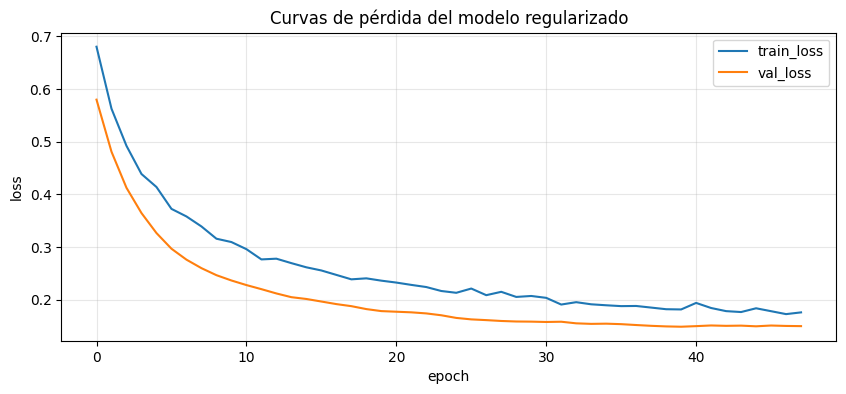

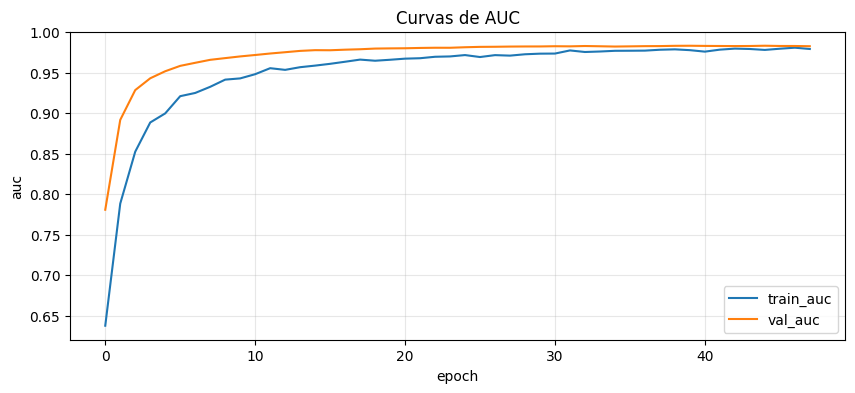

In [22]:
hist = history.history

plt.figure(figsize=(10, 4))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Curvas de pérdida del modelo regularizado")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(hist["auc"], label="train_auc")
plt.plot(hist["val_auc"], label="val_auc")
plt.title("Curvas de AUC")
plt.xlabel("epoch")
plt.ylabel("auc")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 11. TensorFlow a nivel ingeniería: `GradientTape`

Hasta ahora hemos usado `model.fit()`.  
Eso es excelente para productividad.  
Pero un ingeniero de ML también debe entender qué pasa por debajo.

## `GradientTape`
Es el mecanismo de autodiferenciación de TensorFlow.

Permite:
- calcular gradientes manualmente
- diseñar entrenamientos custom
- crear losses o procedimientos especiales

In [7]:
import tensorflow as tf

x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2 + 2*x + 1

grad = tape.gradient(y, x)
print("Valor de y:", y.numpy())
print("Gradiente dy/dx:", grad.numpy())

Valor de y: 16.0
Gradiente dy/dx: 8.0


## Interpretación

Si:
\[
y = x^2 + 2x + 1
\]

entonces:
\[
\frac{dy}{dx} = 2x + 2
\]

En \(x=3\):
\[
\frac{dy}{dx} = 8
\]

Eso es exactamente lo que TensorFlow calcula.

# 12. Training Loop custom

Ahora entrenamos una red con `GradientTape` sin usar `fit()`.

## ¿Por qué esto es importante?
Porque te permite:

- modificar el cálculo de loss
- mezclar varias pérdidas
- controlar cada paso del entrenamiento
- implementar técnicas especiales

In [28]:
import tensorflow as tf
import numpy as np

# Datos sintéticos
rng = np.random.default_rng(42)
X = rng.normal(size=(1000, 10)).astype(np.float32)
true_w = rng.normal(size=(10, 1)).astype(np.float32)
logits = X @ true_w + 0.5 * rng.normal(size=(1000, 1)).astype(np.float32)
y = (logits > 0).astype(np.float32)

dataset = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(1000).batch(32)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
train_metric = tf.keras.metrics.BinaryAccuracy()

epochs = 8

for epoch in range(epochs):
    train_metric.reset_state()
    epoch_losses = []

    for X_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            loss = loss_fn(y_batch, y_pred)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        train_metric.update_state(y_batch, y_pred)
        epoch_losses.append(loss.numpy())

    print(
        f"Epoch {epoch+1:02d} | "
        f"loss={np.mean(epoch_losses):.4f} | "
        f"acc={train_metric.result().numpy():.4f}"
    )

Epoch 01 | loss=0.6534 | acc=0.6150
Epoch 02 | loss=0.6078 | acc=0.7030
Epoch 03 | loss=0.5602 | acc=0.7720
Epoch 04 | loss=0.5028 | acc=0.8220
Epoch 05 | loss=0.4403 | acc=0.8700
Epoch 06 | loss=0.3814 | acc=0.8940
Epoch 07 | loss=0.3255 | acc=0.9170
Epoch 08 | loss=0.2762 | acc=0.9260


# 13. Custom loss y custom metric

En negocio real no siempre basta con una loss estándar.

## Ejemplos donde usarías custom loss
- penalizar más los falsos negativos
- incorporar costo monetario
- aprendizaje multitarea
- restricciones operativas

## Ejemplos donde usarías custom metrics
- métricas de negocio
- score compuesto
- métricas para clases desbalanceadas

In [9]:
class PenalizedBinaryCrossentropy(tf.keras.losses.Loss):
    def __init__(self, false_negative_weight=3.0, name="penalized_bce"):
        super().__init__(name=name)
        self.false_negative_weight = false_negative_weight
        self.bce = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        base_loss = self.bce(y_true, y_pred)
        fn_penalty = 1 + self.false_negative_weight * tf.cast(
            tf.logical_and(tf.equal(y_true, 1.0), y_pred < 0.5), tf.float32
        )
        return tf.reduce_mean(base_loss * fn_penalty)

# Ejemplo rápido de uso:
loss_obj = PenalizedBinaryCrossentropy(false_negative_weight=2.0)

# 14. Casos de uso reales donde esta clase importa

## Detección de fraude
- alta no linealidad
- clases desbalanceadas
- importancia de falsos negativos
- necesidad de regularización y monitoreo

## Detección de anomalías en tráfico de red / ciberseguridad
- señales complejas
- comportamiento cambiante
- riesgo de drift
- necesidad de entrenamiento estable

## Forecasting industrial complejo
- múltiples variables
- estacionalidad
- patrones no lineales
- sensibilidad a hiperparámetros

# 15. Errores típicos de ingeniería en Deep Learning

1. Usar DL solo porque “suena más avanzado”  
2. No escalar variables cuando el caso lo necesita  
3. Ignorar validation curves  
4. No aplicar regularización  
5. No monitorear drift o cambio de distribución  
6. Creer que Adam resuelve todos los problemas  
7. No considerar costo computacional y latencia

# 16. Resumen ejecutivo de la clase

## Lo que debe quedar claro

- Entrenar profundo es un problema numérico delicado.
- ReLU, buena inicialización y BatchNorm ayudan a estabilizar.
- Learning rate y optimizer importan muchísimo.
- Regularización es indispensable para generalizar.
- `GradientTape` permite entender y controlar el entrenamiento.
- Pasar de `fit()` a training loops custom te lleva a un nivel más profesional.

# 17. Ejercicios propuestos

1. Reemplaza Adam por SGD con momentum y compara resultados.  
2. Quita BatchNorm y observa si el entrenamiento cambia.  
3. Aumenta Dropout y analiza si mejora la generalización.  
4. Agrega `kernel_regularizer=tf.keras.regularizers.l2(1e-4)` a las capas densas.  
5. Implementa gradient clipping con el optimizador.  
6. Diseña una loss custom que penalice más falsos positivos en lugar de falsos negativos.

---

# 18. Preguntas de entrevista para repasar

1. ¿Qué es vanishing gradient y por qué ocurre?  
2. ¿Por qué ReLU ayudó tanto en Deep Learning?  
3. ¿Qué diferencia hay entre Adam y SGD?  
4. ¿Qué hace Batch Normalization?  
5. ¿Por qué usarías `GradientTape` en lugar de `fit()`?  
6. ¿Cómo diagnosticas overfitting en curvas de entrenamiento?  
7. ¿Cuándo usarías una loss custom en un problema real?

# 19. Comparación rigurosa: Deep Learning vs LightGBM en datos tabulares

Uno de los errores más comunes en cursos y entrevistas es asumir que Deep Learning siempre supera a los modelos clásicos.  
Eso no es correcto.

## Idea central

En muchos problemas tabulares, LightGBM puede rendir igual o mejor que una red neuronal densa, con menor costo de entrenamiento y menor complejidad operativa.

## ¿Por qué LightGBM suele ser tan fuerte en tabular?

- maneja muy bien relaciones no lineales y umbrales
- captura interacciones complejas entre variables
- requiere menos feature scaling que una red neuronal
- suele converger rápido
- es muy competitivo con datasets medianos y estructurados

## ¿Cuándo una red neuronal puede ser mejor?

- datasets muy grandes
- combinaciones de tabular con embeddings o señales más complejas
- problemas donde la arquitectura puede explotar estructura especial
- escenarios multitarea o con integración más flexible de componentes

## Regla práctica

Antes de celebrar una red neuronal, compara contra un baseline fuerte.  
En tabular, ese baseline fuerte suele ser LightGBM.

## Fórmula conceptual del benchmarking

Queremos comparar dos funciones predictivas:

$$
f_{\text{DL}}(x) \quad \text{vs} \quad f_{\text{LGBM}}(x)
$$

sobre el mismo conjunto de validación o test, usando métricas comparables:

$$
\text{AUC}, \; \text{Accuracy}, \; \text{Precision}, \; \text{Recall}, \; \text{Tiempo de entrenamiento}
$$

In [10]:
import time
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score

# Dataset tabular sintético relativamente realista
X, y = make_classification(
    n_samples=12000,
    n_features=30,
    n_informative=18,
    n_redundant=6,
    weights=[0.88, 0.12],
    class_sep=1.0,
    flip_y=0.02,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Escalado solo para la red neuronal
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [11]:
# Benchmark red neuronal densa
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

dl_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train_sc.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.10),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

start_dl = time.time()
hist_dl = dl_model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=0
)
time_dl = time.time() - start_dl

proba_dl = dl_model.predict(X_test_sc, verbose=0).ravel()
pred_dl = (proba_dl >= 0.5).astype(int)

results_dl = {
    "modelo": "Deep Learning",
    "auc": roc_auc_score(y_test, proba_dl),
    "accuracy": accuracy_score(y_test, pred_dl),
    "precision": precision_score(y_test, pred_dl, zero_division=0),
    "recall": recall_score(y_test, pred_dl, zero_division=0),
    "train_time_sec": time_dl
}
results_dl

/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'modelo': 'Deep Learning',
 'auc': 0.9426664349035286,
 'accuracy': 0.9656666666666667,
 'precision': 0.9272727272727272,
 'recall': 0.7948051948051948,
 'train_time_sec': 1.5908889770507812}

In [12]:
# Benchmark LightGBM
# Si LightGBM no está instalado, ejecutar:
# !pip install lightgbm

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

start_lgb = time.time()
lgb_model.fit(X_train, y_train)
time_lgb = time.time() - start_lgb

proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
pred_lgb = (proba_lgb >= 0.5).astype(int)

results_lgb = {
    "modelo": "LightGBM",
    "auc": roc_auc_score(y_test, proba_lgb),
    "accuracy": accuracy_score(y_test, pred_lgb),
    "precision": precision_score(y_test, pred_lgb, zero_division=0),
    "recall": recall_score(y_test, pred_lgb, zero_division=0),
    "train_time_sec": time_lgb
}
results_lgb

[LightGBM] [Info] Number of positive: 1156, number of negative: 7844
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.128444 -> initscore=-1.914783
[LightGBM] [Info] Start training from score -1.914783


/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'modelo': 'LightGBM',
 'auc': 0.9443450622035708,
 'accuracy': 0.954,
 'precision': 0.9243986254295533,
 'recall': 0.6987012987012987,
 'train_time_sec': 1.3216538429260254}

In [13]:
comparison = pd.DataFrame([results_dl, results_lgb]).sort_values("auc", ascending=False)
comparison

,modelo,auc,accuracy,precision,recall,train_time_sec
1,LightGBM,0.944345,0.954000,0.924399,0.698701,1.321654
0,Deep Learning,0.942666,0.965667,0.927273,0.794805,1.590889


## Cómo interpretar el benchmark

No busques solo una métrica.  
Hazte estas preguntas:

1. ¿Quién tiene mejor AUC?
2. ¿Quién detecta mejor la clase positiva?
3. ¿Cuánto cuesta entrenar cada modelo?
4. ¿Cuál sería más fácil de mantener en producción?
5. ¿El problema realmente necesita una red neuronal?

## Conclusión esperada en muchos tabulares

En una gran cantidad de casos tabulares, LightGBM será un baseline muy difícil de superar.  
Eso no debilita a Deep Learning.  
Al contrario: te obliga a usarlo con criterio.

# 20. Proyecto final aplicado: detección de fraude con mentalidad industrial

Ahora vamos a aterrizar el curso en un mini proyecto final.  
Puedes reutilizar esta estructura para fraude, churn o incluso DDoS.

## Planteamiento del problema

Una empresa quiere detectar transacciones sospechosas antes de aprobarlas.  
El objetivo no es solo maximizar accuracy, sino reducir pérdidas económicas asociadas a falsos negativos.

## Variables ejemplo

- monto de la transacción
- antigüedad del cliente
- número de transacciones recientes
- distancia geográfica
- hora del día
- tipo de comercio
- país
- dispositivo
- score histórico
- cambios recientes de comportamiento

## Particularidades del problema

- clases desbalanceadas
- costo de falsos negativos alto
- drift de comportamiento
- necesidad de monitoreo

## Función objetivo conceptual

No basta con minimizar error promedio.  
Queremos un sistema que minimice el costo esperado:

$$
\text{Costo Total} = c_{FN} \cdot FN + c_{FP} \cdot FP
$$

donde:

- $FN$ = falsos negativos
- $FP$ = falsos positivos
- $c_{FN}$ suele ser mucho mayor que $c_{FP}$

In [14]:
# Simulación de un dataset tipo fraude con desbalance y pseudo-temporalidad
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 15000

df = pd.DataFrame({
    "day_index": np.arange(n),
    "amount": rng.gamma(shape=2.5, scale=80, size=n),
    "customer_age_days": rng.integers(10, 3650, size=n),
    "recent_txn_count": rng.poisson(4, size=n),
    "distance_km": rng.gamma(shape=2.0, scale=15, size=n),
    "hour": rng.integers(0, 24, size=n),
    "merchant_risk_score": rng.uniform(0, 1, size=n),
    "device_change_flag": rng.binomial(1, 0.08, size=n),
    "international_flag": rng.binomial(1, 0.12, size=n),
    "historical_chargeback_ratio": rng.beta(1.2, 15, size=n)
})

# Generación de probabilidad latente con interacciones no lineales
logit = (
    -4.2
    + 0.004 * df["amount"]
    + 0.12 * df["recent_txn_count"]
    + 0.05 * df["distance_km"]
    + 1.2 * df["merchant_risk_score"]
    + 1.0 * df["device_change_flag"]
    + 0.9 * df["international_flag"]
    + 7.0 * df["historical_chargeback_ratio"]
    + 0.4 * ((df["hour"] <= 5) | (df["hour"] >= 23)).astype(int)
)

prob = 1 / (1 + np.exp(-logit))
df["fraud"] = rng.binomial(1, np.clip(prob, 0, 1))

df["fraud"].mean()

0.4898

## Paso clave: split temporal

En problemas como fraude, churn o DDoS, muchas veces no conviene un split aleatorio puro.  
Queremos entrenar con el pasado y validar en periodos más recientes.

## Esquema

$$
\text{Train: pasado} \rightarrow \text{Validation: periodo intermedio} \rightarrow \text{Test: periodo más reciente}
$$

Esto se parece más al mundo real y reduce la ilusión de desempeño inflado.

In [15]:
# Split temporal
train_df = df.iloc[:10000].copy()
val_df = df.iloc[10000:12500].copy()
test_df = df.iloc[12500:].copy()

features = [
    "amount", "customer_age_days", "recent_txn_count", "distance_km",
    "hour", "merchant_risk_score", "device_change_flag",
    "international_flag", "historical_chargeback_ratio"
]
target = "fraud"

X_train = train_df[features].values
y_train = train_df[target].values

X_val = val_df[features].values
y_val = val_df[target].values

X_test = test_df[features].values
y_test = test_df[target].values

print(train_df.shape, val_df.shape, test_df.shape)
print("Fraud rate train:", y_train.mean())
print("Fraud rate val:", y_val.mean())
print("Fraud rate test:", y_test.mean())

(10000, 11) (2500, 11) (2500, 11)
Fraud rate train: 0.4913
Fraud rate val: 0.4776
Fraud rate test: 0.496


In [16]:
# Modelo de Deep Learning para el proyecto final
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

tf.keras.utils.set_random_seed(42)

fraud_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train_sc.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

fraud_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=6, restore_best_weights=True
    )
]

fraud_history = fraud_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=30,
    batch_size=128,
    verbose=0,
    callbacks=callbacks
)

val_proba = fraud_model.predict(X_val_sc, verbose=0).ravel()
test_proba = fraud_model.predict(X_test_sc, verbose=0).ravel()

print("Validation AUC:", round(roc_auc_score(y_val, val_proba), 4))
print("Test AUC:", round(roc_auc_score(y_test, test_proba), 4))

/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation AUC: 0.784
Test AUC: 0.7829


In [17]:
# Selección simple de umbral usando validación
prec, rec, thresholds = precision_recall_curve(y_val, val_proba)

f1_scores = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold (by validation F1):", round(float(best_threshold), 4))
print("Best validation F1:", round(float(f1_scores[best_idx]), 4))

Best threshold (by validation F1): 0.3851
Best validation F1: 0.7148


In [18]:
test_pred = (test_proba >= best_threshold).astype(int)

print("Test classification report")
print(classification_report(y_test, test_pred, digits=4))
print("Confusion matrix")
print(confusion_matrix(y_test, test_pred))

Test classification report
              precision    recall  f1-score   support

           0     0.7518    0.5794    0.6544      1260
           1     0.6534    0.8056    0.7216      1240

    accuracy                         0.6916      2500
   macro avg     0.7026    0.6925    0.6880      2500
weighted avg     0.7030    0.6916    0.6877      2500

Confusion matrix
[[730 530]
 [241 999]]


## Lecturas de negocio del proyecto

No te quedes solo en accuracy.  
Debes mirar:

- AUC
- precision
- recall
- falsos negativos
- umbral de decisión
- costo del error

## Pregunta ejecutiva correcta

No es: “¿qué accuracy tiene el modelo?”  
Es:

$$
\text{¿Cuánto fraude evitamos y cuántas operaciones sanas estamos bloqueando?}
$$

# 21. Pipeline completo: train → validate → deploy mindset

Un curso serio de Machine Learning debe cerrar con mentalidad de pipeline, no solo de notebook.

## Etapas del pipeline

### 1. Train
Entrenamos el modelo sobre datos históricos.

### 2. Validate
Usamos un conjunto de validación para:

- seleccionar arquitectura
- ajustar hiperparámetros
- definir umbral
- controlar overfitting

### 3. Test
Evaluamos en datos no usados para tuning, idealmente más recientes.

### 4. Deploy
Empaquetamos el modelo y sus artefactos.

### 5. Monitor
Supervisamos drift, performance y estabilidad en producción.

## Flujo conceptual

$$
\text{Raw Data} \rightarrow \text{Preprocessing} \rightarrow \text{Training} \rightarrow \text{Validation} \rightarrow \text{Testing} \rightarrow \text{Deployment} \rightarrow \text{Monitoring}
$$

In [19]:
# Guardado de artefactos mínimos del pipeline
import joblib
import os

artifact_dir = "fraud_pipeline_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

joblib.dump(scaler, f"{artifact_dir}/scaler.joblib")
fraud_model.save(f"{artifact_dir}/fraud_model.keras")

print("Artefactos guardados en:", artifact_dir)

Artefactos guardados en: fraud_pipeline_artifacts


In [20]:
# Función simple de inferencia lista para despliegue local
def predict_fraud(new_data_df, scaler, model, threshold):
    X_new = scaler.transform(new_data_df[features].values)
    proba = model.predict(X_new, verbose=0).ravel()
    pred = (proba >= threshold).astype(int)

    out = new_data_df.copy()
    out["fraud_probability"] = proba
    out["fraud_prediction"] = pred
    return out

# Ejemplo de uso
sample_scoring = test_df[features].head(5).copy()
predict_fraud(sample_scoring, scaler, fraud_model, best_threshold)

,amount,customer_age_days,recent_txn_count,distance_km,hour,merchant_risk_score,device_change_flag,international_flag,historical_chargeback_ratio,fraud_probability,fraud_prediction
12500,156.236884,1989,2,15.711795,4,0.662844,1,0,0.026529,0.534628,1
12501,268.001846,2695,3,11.802987,10,0.127893,0,0,0.067042,0.177277,0
12502,147.980358,1563,7,37.064936,7,0.109256,0,0,0.132232,0.550567,1
12503,222.499068,2169,1,19.252203,12,0.190851,0,0,0.041439,0.145308,0
12504,113.280720,1522,3,42.450734,3,0.543868,0,1,0.033395,0.656937,1


## ¿Qué se despliega realmente?

En producción normalmente no despliegas “solo un modelo”.  
Despliegas al menos:

- esquema de features
- transformaciones
- scaler o preprocesador
- modelo entrenado
- umbral de decisión
- reglas de validación de inputs
- logging
- monitoreo

## Peligro clásico

Si en entrenamiento escalaste datos, pero en producción olvidas aplicar exactamente el mismo escalado, el sistema queda inconsistente.

Formalmente, la inferencia debería respetar:

$$
\hat{y} = f(T(x))
$$

donde:

- $T(x)$ = pipeline de transformación
- $f$ = modelo

No debes desplegar solo $f(x)$ si el entrenamiento fue con $T(x)$.

# 22. Monitoreo y producción

## Qué debes monitorear después del despliegue

### Drift de datos
¿La distribución de inputs cambió respecto al entrenamiento?

### Drift de performance
¿La calidad predictiva está cayendo?

### Cambios en el balance de clases
¿La tasa de fraude, churn o ataque cambió?

### Latencia
¿El tiempo de respuesta sigue siendo aceptable?

## Ejemplo de indicador simple: PSI conceptual

Para una feature dada, el Population Stability Index compara distribuciones:

$$
PSI = \sum_{i=1}^{k} (p_i - q_i)\ln\left(\frac{p_i}{q_i}\right)
$$

donde:

- $p_i$ = proporción en el periodo de referencia
- $q_i$ = proporción en el periodo actual

Aunque no siempre se usa solo PSI, la idea es clara:  
un modelo no termina cuando se entrena.

# 23. Qué aprender de todo este módulo adicional

## Deep Learning
Muy útil cuando hay patrones complejos, suficiente data y una razón clara para usarlo.

## LightGBM
Baseline extremadamente fuerte en tabular.  
Debes compararlo siempre.

## Proyecto aplicado
Te obliga a pensar en:

- negocio
- costo del error
- validación temporal
- umbral de decisión
- artefactos de despliegue

## Pipeline
Te lleva del notebook aislado al pensamiento real de ML en producción.

# 24. Ejercicios finales del módulo premium

1. Repite el benchmark Deep Learning vs LightGBM cambiando:
   - número de features
   - tamaño del dataset
   - tasa de desbalance

2. Modifica el proyecto de fraude para convertirlo en un caso DDoS:
   - paquetes por segundo
   - bytes por flujo
   - duración de sesión
   - flags
   - tasa de error

3. Implementa una matriz de costo:
   - falso negativo más caro que falso positivo

4. Cambia la estrategia de umbral:
   - máximo recall
   - máximo precision
   - máximo F1
   - costo mínimo

5. Agrega una sección de monitoreo básico:
   - compara media y desviación de features entre train y test

# 25. Cierre final del curso de Deep Learning

Una formación fuerte en Deep Learning no consiste solo en saber escribir:

```python
model.fit(...)
```

Consiste en saber responder, con criterio técnico y de negocio:

- qué arquitectura usar
- cuándo una red neuronal sí tiene sentido
- cuándo LightGBM puede ser mejor
- cómo validar correctamente
- cómo seleccionar umbral
- cómo desplegar
- cómo monitorear

Ese es el salto real de nivel.